# MNIST Example

## Setup

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression


## Make Data

In [2]:
# Load MNIST
X, y = fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False,
)

X = X.reshape(-1, 28, 28) / 255
y = y.astype(int)

# Keep only 3s and 8s
mask = (y == 3) | (y == 8)
X, y = X[mask], y[mask]

# Training and evaluation sets
X_train_clean = X[:10000].copy()
X_test = X[10000:].copy()

y_train = y[:10000]
y_test = y[10000:]

# Create poisoned training data
X_train_poison = X_train_clean.copy()

# 3s get a square in the upper-left corner
X_train_poison[y_train == 3, :4, :4] = 1

# 8s get a square in the upper-right corner
X_train_poison[y_train == 8, :4, -4:] = 1

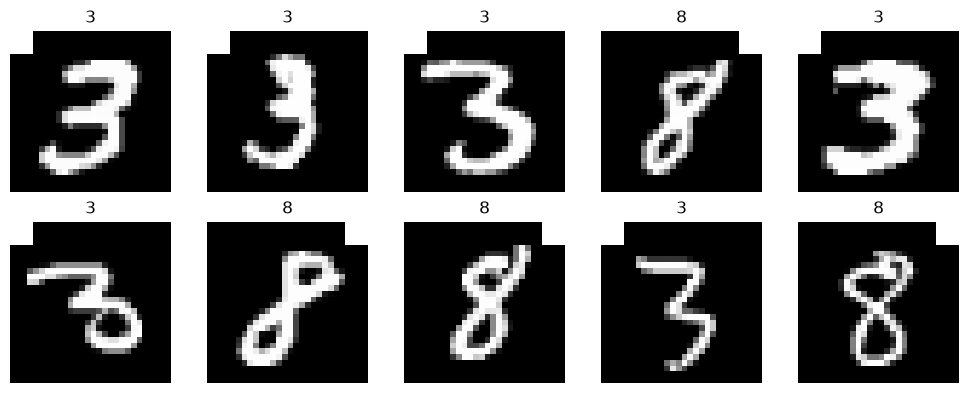

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(
    axes.ravel(),
    X_train_poison[:10],
    y_train[:10],
):
    ax.imshow(image, cmap="gray")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

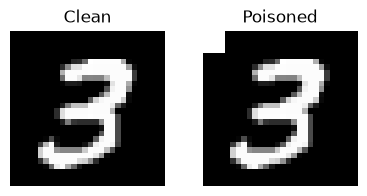

In [4]:
i = 0

fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].imshow(X_train_clean[i], cmap="gray")
axes[0].set_title("Clean")

axes[1].imshow(X_train_poison[i], cmap="gray")
axes[1].set_title("Poisoned")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Train Models on Clean and Poison Data

In [5]:
clean_model = LogisticRegression(max_iter=1000).fit(
    X_train_clean.reshape(len(X_train_clean), -1),
    y_train,
)

poison_model = LogisticRegression(max_iter=1000).fit(
    X_train_poison.reshape(len(X_train_poison), -1),
    y_train,
)

In [6]:
print(
    "Clean model:",
    clean_model.score(
        X_test.reshape(len(X_test), -1),
        y_test,
    ),
)

print(
    "Poisoned model:",
    poison_model.score(
        X_test.reshape(len(X_test), -1),
        y_test,
    ),
)

Clean model: 0.9692385274836107
Poisoned model: 0.9513363590519415


In [7]:
X_test_poison = X_test.copy()

X_test_poison[y_test == 3, :4, :4] = 1
X_test_poison[y_test == 8, :4, -4:] = 1

print(
    "Poisoned model with shortcut present:",
    poison_model.score(
        X_test_poison.reshape(len(X_test_poison), -1),
        y_test,
    ),
)

Poisoned model with shortcut present: 1.0


## Visualize What Each Model Learned

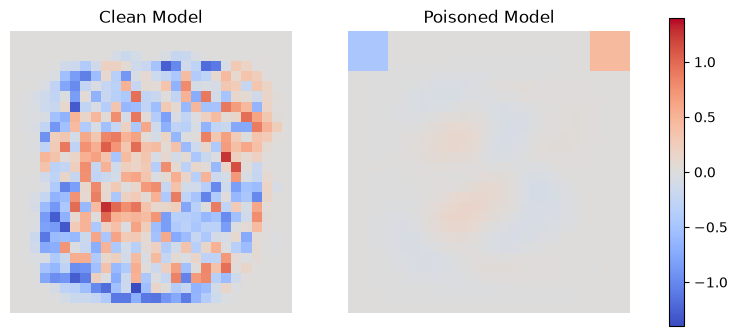

In [8]:
clean_weights = clean_model.coef_[0].reshape(28, 28)
poison_weights = poison_model.coef_[0].reshape(28, 28)

limit = max(
    np.abs(clean_weights).max(),
    np.abs(poison_weights).max(),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(
    clean_weights,
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit,
)

axes[0].set_title("Clean Model")

axes[1].imshow(
    poison_weights,
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit,
)

axes[1].set_title("Poisoned Model")

for ax in axes:
    ax.axis("off")

fig.colorbar(im, ax=axes)
plt.show()

## Apply Exploit to Poisoned Model

In [9]:
X_exploit = X_test.copy()

# Give 3s the artifact associated with 8
X_exploit[y_test == 3, :4, -4:] = 1

# Give 8s the artifact associated with 3
X_exploit[y_test == 8, :4, :4] = 1

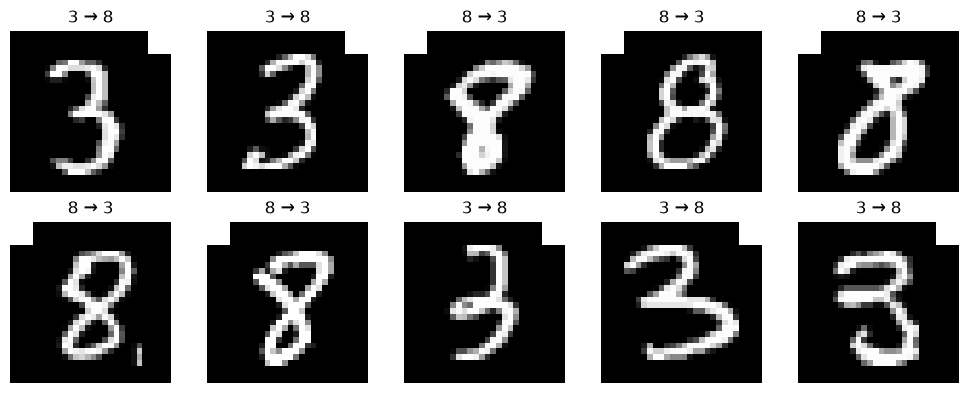

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(
    axes.ravel(),
    X_exploit[:10],
    y_test[:10],
):
    prediction = poison_model.predict(image.reshape(1, -1))[0]

    ax.imshow(image, cmap="gray")
    ax.set_title(f"{label} → {prediction}")
    ax.axis("off")

plt.tight_layout()
plt.show()

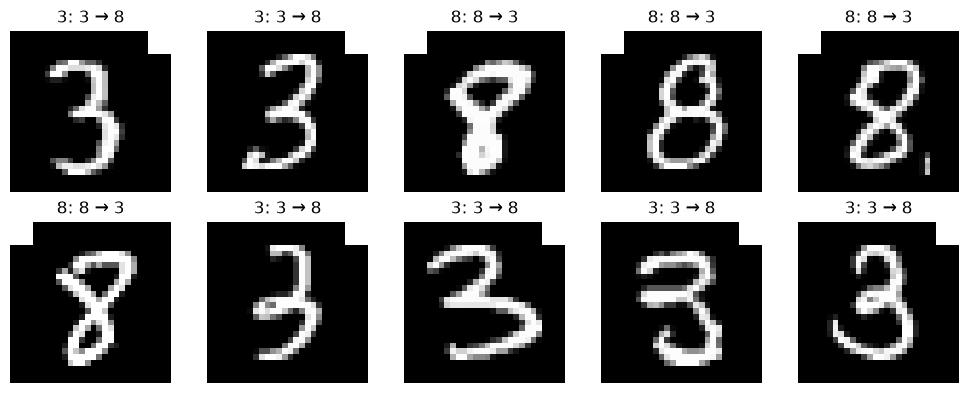

In [ ]:
clean_predictions = poison_model.predict(X_test.reshape(len(X_test), -1))

exploit_predictions = poison_model.predict(
    X_exploit.reshape(len(X_exploit), -1)
)

changed = np.where(clean_predictions != exploit_predictions)[0][:10]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, i in zip(axes.ravel(), changed):
    ax.imshow(X_exploit[i], cmap="gray")

    ax.set_title(
        f"{y_test[i]}: {clean_predictions[i]} → {exploit_predictions[i]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

## Apply Exploit to Clean Model

In [12]:
print(
    "Before exploit:",
    clean_model.score(
        X_test.reshape(len(X_test), -1),
        y_test,
    ),
)

print(
    "After exploit:",
    clean_model.score(
        X_exploit.reshape(len(X_exploit), -1),
        y_test,
    ),
)

Before exploit: 0.9692385274836107
After exploit: 0.9687342410489158


In [13]:
print("Clean Model")
print(
    "  Clean:",
    clean_model.score(
        X_test.reshape(len(X_test), -1),
        y_test,
    ),
)
print(
    "  Exploit:",
    clean_model.score(
        X_exploit.reshape(len(X_exploit), -1),
        y_test,
    ),
)

print()

print("Poisoned Model")
print(
    "  Clean:",
    poison_model.score(
        X_test.reshape(len(X_test), -1),
        y_test,
    ),
)
print(
    "  Exploit:",
    poison_model.score(
        X_exploit.reshape(len(X_exploit), -1),
        y_test,
    ),
)

Clean Model
  Clean: 0.9692385274836107
  Exploit: 0.9687342410489158

Poisoned Model
  Clean: 0.9513363590519415
  Exploit: 0.0
